In [1]:
from itertools import *
import seaborn as sea
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D
from ase import Atoms
from ase.visualize import view
from random import sample,seed
from shape_proj_util.geo_tools.geometry import *
from ase.io.xyz import write_xyz
from scipy.spatial.distance import cdist
import random
from tqdm.auto import tqdm
from scipy.spatial import ConvexHull

In [2]:
#a: lattice constant
#x,y,z are how many times lattice extends along this direction
#x,y,z must large than 1
def fccbasis(a):
    fcc = [[0,0.5*a,0.5*a],[0.5*a,0,0.5*a],[0.5*a,0.5*a,0],[0,0,0],\
                    [0,0,a],[0,a,0],[a,0,0],[a,a,0],\
                    [0,a,a],[a,0,a],[a,a,a],[a,0.5*a,0.5*a],\
                    [0.5*a,a,0.5*a],[0.5*a,0.5*a,a]]
    return np.array(fcc)

#lattice is an array containing coordinates in fcc
def extendfcc(lattice,a,x,y,z):
    lattice_extend = []
    for i in range(0,x):
        for j in range(0,y):
            for k in range(0,z):
                for o in range(0,len(lattice)):
                    if not lattice_extend.__contains__([lattice[o][0]+i*a,lattice[o][1]+j*a,lattice[o][2]+k*a]):
                        lattice_extend.extend([[lattice[o][0]+i*a,lattice[o][1]+j*a,lattice[o][2]+k*a]])
    return np.array(lattice_extend)

In [4]:
#gauss
#making lattice

def empty_lattice(lc,n1,n2,n3):
    """
    Generate a fcc lattice by given lattice constant and superlattice parameters: n1,n2,n3.
    The constructed lattice is centered at (0,0,0), and the coordinates are reordered by the 
    atom to center distance.
    @param lc: lattice constant
    @param n1: superlattice parameter: number of cells on x direction
    @param n2: superlattice parameter: number of cells on y direction
    @param n3: superlattice parameter: number of cells on z direction
    @param mid_position: the position of the center of the lattice, if None, the center of the lattice is set to (0,0,0)
    return: ordered lattice, mid_position
    """

    # lattice=extendfcc(fccbasis(lc),lc,n1,n2,n3)
    lattice=extendfcc(fccbasis(lc),lc,n1,n2,n3)
    mid_position=np.mean(lattice,axis=0)
    # lattice=np.round(lattice-mid_position,6)
    closest_index=np.where(np.all(np.isclose(mid_position,lattice,rtol=lc/(2*np.sqrt(2))),axis=1))[0][0]
    lattice=lattice-lattice[closest_index]
    return order_pos(lattice)

def order_pos(lattice,mid_position=None):
    if mid_position is None:
        mid_position=np.mean(lattice,axis=0)
    # reorder the lattice by distance to the center. The first atom is the closest to the center.
    dist=np.round(cdist([mid_position],lattice),6)
    dist_dict=Counter(dist[0])
    sorted_count=sorted(dist_dict.items(),key=lambda x:x[0],reverse=False)
    record=[]
    ordered_particle=[]
    for i in range(len(sorted_count)):
        record.extend(np.where(dist==sorted_count[i][0])[1])
    for i in range(len(lattice)):
        ordered_particle.append(lattice[record[i]])
    return np.array(ordered_particle)

def particles_encode_gen_no_oblate(lc,num_atoms=None,max_num_atoms=None):
    if num_atoms==None:
        assert max_num_atoms!=None,"Please provide the maximum number of atoms in the lattice."
        num_atoms=random.randint(12,max_num_atoms) 
    # min_num_points=num_atoms
    num_lattice=max_num_atoms//2
    n_max=int(np.ceil(np.cbrt(num_lattice)))
    num_points=0
    lattice_big=empty_lattice(lc,n_max,n_max,n_max)
    # transfer points to the big lattice
    indices=[]
    genome=np.zeros(len(lattice_big))
    for i in range(num_atoms):
        indices.extend(np.where(np.all(np.isclose(lattice_big,lattice_big[i],rtol=1e-3),axis=1))[0])
    for i in indices:
        genome[i]=1
    return genome,(n_max,n_max,n_max,num_atoms)
# generate random lattice with random n1,n2,n3 of the superlattice parimeters, and random numbers of atoms in the lattice.
def particles_encode_gen(lc,num_atoms=None,max_num_atoms=None):
    if num_atoms==None:
        assert max_num_atoms!=None,"Please provide the maximum number of atoms in the lattice."
        num_atoms=random.randint(12,max_num_atoms) 
    # min_num_points=num_atoms
    num_lattice=max_num_atoms//2
    n_max=int(np.ceil(np.cbrt(num_lattice)))
    num_points=0
    lattice_big=empty_lattice(lc,n_max,n_max,n_max)
    # print(f"length={np.mean(lattice_big,axis=0)}")
    times=random.randint(1,3)

    #this is too strong
    while num_points<num_atoms*2:
        n1=random.randint(1,n_max)
        n2=n1
        n3=random.randint(1,n1)
        
        lattice=empty_lattice(lc,n1,n2,n3)
        num_points=len(lattice)
    # print(f"length={np.mean(lattice,axis=0)}")
    # transfer points to the big lattice
    indices=[]
    genome=np.zeros(len(lattice_big))
    for i in range(num_atoms):
        indices.extend(np.where(np.all(np.isclose(lattice_big,lattice[i],rtol=1e-3),axis=1))[0])
    for i in indices:
        genome[i]=1
    return genome,(n1,n2,n3,num_atoms)

def particles_encode_gen_lattice(lc,n1,n2,n3,num_atoms=None,max_num_atoms=None):
    num_lattice=max_num_atoms//2
    n_max=int(np.ceil(np.cbrt(num_lattice)))
    num_points=0
    lattice_big,mean_position=empty_lattice(lc,n_max,n_max,n_max)
    indices=[]
    lattice=empty_lattice(lc,n1,n2,n3,mean_position)
    num_points=len(lattice)
    genome=np.zeros(len(lattice_big))
    for i in range(num_atoms):
        indices.extend(np.where(np.all(np.isclose(lattice[i],lattice_big,rtol=1e-1),axis=1))[0])
    for i in indices:
        genome[i]=1
    return genome,(n1,n2,n3,num_atoms)

def recon_coordfromcodes(genome,lc,max_num_atoms):
    num_lattice=max_num_atoms//2
    n_max=int(np.ceil(np.cbrt(num_lattice)))
    lattice_big=empty_lattice(lc,n_max,n_max,n_max)
    index=list(np.where(np.array(genome)==1)[0])
    # print(index)
    return np.array(lattice_big[index]),lattice_big

def encode_fromcoord(particle,lc,max_num_atoms):
    index=[]
    num_lattice=max_num_atoms//2
    n_max=int(np.ceil(np.cbrt(num_lattice)))
    lattice=empty_lattice(lc,n_max,n_max,n_max)
    for i in range(len(particle)):
        index.extend(np.where(np.all(np.isclose(particle[i],lattice,rtol=1e-3),axis=1))[0])
    # print(len(particle),len(index))
    genome_recon=np.zeros(len(lattice))
    for i in index:
        genome_recon[i]=1
    return genome_recon
def convex_particle(genome,lc,max_num_atoms):
    indices=[]
    num_lattice=max_num_atoms//2
    n_max=int(np.ceil(np.cbrt(num_lattice)))
    lattice_big=empty_lattice(lc,n_max,n_max,n_max)
    particle,_=recon_coordfromcodes(genome,lc,max_num_atoms)
    hull=ConvexHull(particle)
    # print(hull)
    for points in lattice_big:
        if is_point_in_hull(points,hull):
            indices.extend(np.where(np.all(np.isclose(points,particle,rtol=1e-3),axis=1))[0])
        
    genome_recon=np.zeros(len(lattice_big))
    for i in indices:
        genome_recon[indices[i]]=1
    return genome_recon
def is_point_in_hull(point,hull):
    equations=hull.equations
    return np.all(np.dot(equations[:,:-1],point)+equations[:,-1]<=0)

def ini_population(population_size,max_num_atoms,lc,num_atoms=None):
    generations=[]
    parameters=[]
    n=0
    while n<population_size:
        genome,parameter=particles_encode_gen(lc,num_atoms=num_atoms,max_num_atoms=max_num_atoms)
        #no duplicates
        if parameter not in parameters:
            generations.append(genome)
            parameters.append(parameter)
            n+=1
    #oblate set
    assert(len(set(parameters))==len(parameters))
    return generations,parameters

def fitness(genome,lc,max_num_atoms,descriptors:dict):
    genome=np.array(genome)
    particle,_=recon_coordfromcodes(genome,lc,max_num_atoms)
    atom=Atoms(positions=particle,symbols=['Pt']*len(particle))
    cluster_descriptors=descriptor_table(atom)
    true_dis=np.array([descriptors[k] for k in descriptors.keys()])
    # print(true_dis)
    pred_dis=np.array([cluster_descriptors[k] for k in descriptors.keys()])
    # print(pred_dis)
    #MSE
    return np.sum((true_dis-pred_dis)**2),pred_dis

            
def parents(population,parameters,fitness_values,tol=1e5):
    fitness_values=np.array(fitness_values)
    ranking=ranking_fitness(fitness_values)
    prob=normalized_p(ranking)
    # index=np.arange(len(population))
    # threshold=random.uniform(np.min(prob),np.max(prob))
    current=0
    index=0
    # for i in range(len(population)):
    while index<tol:
        i=random.randint(0,len(population)-1)
        index+=1
        if random.uniform(0,1)<=prob[i]:
            return list(population[i]),parameters[i]
        if index==tol:
            raise Exception("exceed the maximum try times!")
        
        
def ranking_fitness(fitness_values):
    fitness_ranking=np.zeros(len(fitness_values))
    fitness_dict=Counter(fitness_values)
    fitness_ordered=sorted(fitness_dict.keys(),reverse=False)
    rank=1
    for i in range(len(fitness_ordered)):
        indices=np.where(np.array(fitness_values)==fitness_ordered[i])[0]
        for j in indices:
            fitness_ranking[j]=rank
        rank+=1
    return fitness_ranking
def probability_selection(fitness_ranking):
    R=len(fitness_ranking)
    lamb=np.log(10)/(max(fitness_ranking)-min(fitness_ranking))
    # print(lamb)
    z=np.array([np.exp(-lamb*r) for r in fitness_ranking])
    z_sum=np.sum(z)
    return z/z_sum 
def normalized_p(fitness_ranking):
    p=probability_selection(fitness_ranking)
    return (p-np.min(p))/(np.max(p)-np.min(p))

def crossover(lc,parent1,parent2,cross_over_rate=0.6,max_num_atoms=100):
    if random.random()<cross_over_rate:
        theta=random.uniform(0,np.pi)
        phi=random.uniform(0,2*np.pi)
        # parent1_particle=recon_coordfromcodes(parent1,lc,max_num_atoms)
        # parent2_particle=recon_coordfromcodes(parent2,lc,max_num_atoms)
        parent1_up,parent1_down=atom_cut_up_down_center(parent1,theta,phi,lc,max_num_atoms)
        parent2_up,parent2_down=atom_cut_up_down_center(parent2,theta,phi,lc,max_num_atoms)
        parent1=parent1_up+parent2_down
        parent2=parent2_up+parent1_down
        # print(parent1_up,parent2_down)
        # print(parent1_down,parent2_up)
        parent1[parent1>1]=1
        parent2[parent2>1]=1
        return parent1,parent2
    else:
        return parent1,parent2

def mutation(genome,lc,max_num_atoms,mutation_rate=0.3):
    mr=random.random()
    num_atoms=len(np.where(np.array(genome)==1)[0])
    if mr<=mutation_rate/2:
        genome_update=np.zeros(len(genome))
        renum=0
        while len(np.where(np.array(genome_update)==1)[0])<1/3*num_atoms and renum<5:
            theta=random.uniform(0,np.pi)
            phi=random.uniform(0,2*np.pi)
            # if renum==0:
            #     print("no good 1")
            genome_update=atom_trancate_center(genome,theta,phi,lc,max_num_atoms)
            renum+=1
        if renum==5:
            genome_update=genome
    if mr>mutation_rate/2 and mr<=mutation_rate:
        genome_update=np.zeros(len(genome))
        renum=0
        while len(np.where(np.array(genome_update)==1)[0])<1/3*num_atoms and renum<5:
            theta=random.uniform(0,np.pi)
            phi=random.uniform(0,2*np.pi)
            genome_update=atom_trancate_arbi(genome,theta,phi,lc,max_num_atoms)
            renum+=1
        if renum==5:
            genome_update=genome
        
    else:
        genome_update=genome
    return genome_update
    
def atom_cut_up_down_center(genome,theta,phi,lc,max_num_atoms):
    def normal_vector(center,theta,phi):
        return np.array([np.sin(theta)*np.cos(phi),np.sin(theta)*np.sin(phi),np.cos(theta)])
    num_atoms=len(np.where(np.array(genome)==1)[0])
    particle,big_lattice=recon_coordfromcodes(genome,lc,max_num_atoms)
    particle=np.array(particle)
    center=np.mean(particle,axis=0)
    closest_index=np.where(np.all(np.isclose(center,particle,rtol=lc/(1.8*np.sqrt(2))),axis=1))[0][0]
    particle_shift=particle-particle[closest_index]
    center=np.mean(particle_shift,axis=0)
    normal=normal_vector(center,theta,phi)
    
    trancate_up_particle=[]
    trancate_down_particle=[]
    for pos in particle_shift:
        if normal[0]*(pos[0]-center[0])+normal[1]*(pos[1]-center[1])+normal[2]*(pos[2]-center[2])>=-lc/np.sqrt(2):
            trancate_up_particle.append([pos[0],pos[1],pos[2]])
        if normal[0]*(pos[0]-center[0])+normal[1]*(pos[1]-center[1])+normal[2]*(pos[2]-center[2])<=lc/np.sqrt(2):
            trancate_down_particle.append([pos[0],pos[1],pos[2]])
    # print(len(trancate_up_particle))
    # print(len(trancate_down_particle))
    genome_up_recon=encode_fromcoord(trancate_up_particle,lc,max_num_atoms)
    genome_down_recon=encode_fromcoord(trancate_down_particle,lc,max_num_atoms)
    return np.array(genome_up_recon),np.array(genome_down_recon)


def atom_trancate_center(genome,theta,phi,lc,max_num_atoms):
    def normal_vector(center,theta,phi):
        return np.array([np.sin(theta)*np.cos(phi),np.sin(theta)*np.sin(phi),np.cos(theta)])
    num_atoms=len(np.where(np.array(genome)==1)[0])
    particle,big_lattice=recon_coordfromcodes(genome,lc,max_num_atoms)
    particle=np.array(particle)
    center=np.mean(particle,axis=0)
    normal=normal_vector(center,theta,phi)
    trancate_particle=[]
    for pos in particle:
        if normal[0]*(pos[0]-center[0])+normal[1]*(pos[1]-center[1])+normal[2]*(pos[2]-center[2])>=0:
            trancate_particle.append([pos[0],pos[1],pos[2]])
    if len(trancate_particle)<5:
        genome_recon=np.zeros(len(genome))
    else:
        genome_recon=encode_fromcoord(trancate_particle,lc,max_num_atoms)
    # print(f"1={len(genome_recon)}")
    # print(len(particle),len(trancate_particle),len(np.where(np.array(genome_recon)==1)[0]))
    return genome_recon
    
def atom_trancate_arbi(genome,theta,phi,lc,max_num_atoms):
    def normal_vector(center,theta,phi):
        return np.array([np.sin(theta)*np.cos(phi),np.sin(theta)*np.sin(phi),np.cos(theta)])
    num_atoms=len(np.where(np.array(genome)==1)[0])
    particle,big_lattice=recon_coordfromcodes(genome,lc,max_num_atoms)
    particle=np.array(particle)
    center_get=[]
    # for i in range(len(particle)):
    #     CN1,dis=getCN_dis_Oneshell(particle,particle[i],1,thickness=0.1)
    #     if CN1==12:
    #         center_get.append(particle[i])
    # if len(center_get)!=0:
    center=random.choice(particle)
    # else:
    #     return particle
    ## points with coordination numbers are 12 are considered as the center of planes for truncation.
    normal=normal_vector(center,theta,phi)
    trancate_particle=[]
    for pos in particle:
        if normal[0]*(pos[0]-center[0])+normal[1]*(pos[1]-center[1])+normal[2]*(pos[2]-center[2])>=0:
            trancate_particle.append([pos[0],pos[1],pos[2]])  
    # print(f"len(trancate_particle)={len(trancate_particle)}")
    if len(trancate_particle)<5:
        trancate_particle=[]
        for pos in particle:
            if normal[0]*(pos[0]-center[0])+normal[1]*(pos[1]-center[1])+normal[2]*(pos[2]-center[2])<=0:
                trancate_particle.append([pos[0],pos[1],pos[2]])
        # print(f"len(trancate_particle)={len(trancate_particle)}")
    
    genome_recon=encode_fromcoord(trancate_particle,lc,max_num_atoms)
    return genome_recon
def convex_particle(genome,lc,max_num_atoms):
    indices=[]
    num_lattice=max_num_atoms//2
    n_max=int(np.ceil(np.cbrt(num_lattice)))
    lattice_big=empty_lattice(lc,n_max,n_max,n_max)
    particle,_=recon_coordfromcodes(genome,lc,max_num_atoms)
    hull=ConvexHull(particle)
    for points in lattice_big:
        if is_point_in_hull(points,hull,lc):
            indices.extend(np.where(np.all(np.isclose(points,lattice_big,rtol=1e-1),axis=1))[0])
    # print(len(indices))
    # print(len(particle))
    genome_recon=np.zeros(len(lattice_big))
    for i in indices:
        genome_recon[i]=1
    return genome_recon
def is_point_in_hull(point,hull,lc):
    equations=hull.equations
    # print(np.all(np.dot(equations[:,:-1],point)+equations[:,-1]<=0))
    return np.all(np.dot(equations[:,:-1],point)+equations[:,-1]<=lc/(2*np.sqrt(2)))
        

def genetic_algorithm(max_num_atoms=200,
                      generations=100,
                      population_size=100,
                      lc=3.77,
                      mutation_rate=0.3,
                      cross_over_rate=0.3,
                      shell=1,
                      descriptors={"surface ratio": 1,
                                    "flatten": 0.7,
                                    "atom_number": 50
                      }
                # "CN1":6,
                # "CN2":1.5,
                # "CN3":2,
                # "CN4":5

    ):
    #1. set up parameters

    print(descriptors)
    num_lattice=max_num_atoms//2 #since one unit cell of fcc lattice has 2 atoms
    n_max=int(np.ceil(np.cbrt(num_lattice)))
    lattice_big=empty_lattice(lc,n_max,n_max,n_max)

    #2. initialization of populations
    populations,parameters = ini_population(lc=lc,
                                population_size=population_size,
                                max_num_atoms=max_num_atoms,
                                num_atoms=None)
    # populations_ini_mute=[]
    # for i in range(len(populations)):
    #     populations_ini_mute.append(mutation(populations[i],lc,max_num_atoms,mutation_rate=0.5))
    ini_population_record=populations.copy()
    fitness_record=[]
    best_particle=[]
    #3. calculate fitness for populations
    fitness_values=[fitness(genome,lc,max_num_atoms,descriptors)[0] for genome in populations]
    #4. start iteration
    for generation in tqdm(range(generations)):
        # clustering_energy_values=[clustering_energy(genome,lattice) for genome in population]
        #(1). generate new populations
        new_populations = []
       
        #check duplicates, if duplicates exist, then generate a new structure
        for _ in range(population_size//2):
            #[1]. find parents from populations based on fitness values
            # print(len(populations),len(parameters),len(fitness_values))
            parent1,parameters1=parents(populations,parameters,fitness_values)
            parent2,parameters2=parents(populations,parameters,fitness_values)
            fit_parent1=fitness(parent1,lc,max_num_atoms,descriptors)
            fit_parent2=fitness(parent2,lc,max_num_atoms,descriptors)
            #[2]. crossover and mutation to generate offsprings
            children1,children2=crossover(lc,parent1,parent2,cross_over_rate=cross_over_rate,max_num_atoms=max_num_atoms)
            children1=convex_particle(children1,lc,max_num_atoms)
            children2=convex_particle(children2,lc,max_num_atoms)
            # print(f"children={len(np.where(np.array(children1)==1)[0]),len(np.where(np.array(children2)==1)[0])}")
            children1=mutation(children1,lc,max_num_atoms,mutation_rate=mutation_rate)
            children2=mutation(children2,lc,max_num_atoms,mutation_rate=mutation_rate)
            #convex hull

            # children1=convex_particle(children1,shell,lc,max_num_atoms)
            # children2=convex_particle(children2,shell,lc,max_num_atoms)
            new_populations.extend([children1,children2])
        
        #(2). calculate fitness for new populations and obtain the predicted descriptors
        fitness_values=[]
        predict_values=[]
        for genome in new_populations:
            # print(f"genome={genome}")
            fitness_cal=fitness(genome,lc,max_num_atoms,descriptors)
            fitness_values.append(fitness_cal[0])
            predict_values.append(fitness_cal[1])
        # clustering_energy_values=[clustering_energy(genome,lattice) for genome in population]
        #(3). find the best solution
        #[1]. best fitness value and prediction
        best_fitness=min(fitness_values)
        ave_fitness=np.mean(fitness_values)
        best_predict=predict_values[fitness_values.index(best_fitness)]
        best_index=fitness_values.index(best_fitness)
        #[2]. reconstruct the best solution from codes using new_populations.
        particle,_=recon_coordfromcodes(new_populations[best_index],lc,max_num_atoms)
        # best_clustering_energy=min(clustering_energy_values)
        #[3]. record the reconstructed particles using Atoms objects.
        best_particle.append(Atoms(positions=particle,symbols=['Pt']*len(particle)))
        fitness_record.append(ave_fitness)                         #dong
        #[4]. print output
        print(f"Generation{generation}:ave Finess={ave_fitness},best Predict={best_predict}")
        #[5]. update populations
        populations=new_populations
        #[6]. early stopping
        # if generation>10:
        #     error=fitness_record[generation-1]-fitness_record[generation]
        #     if error<1e-4:
        #         break
    #4. record the best solution
    best_index=fitness_values.index(best_fitness)
    print(f"best_index={best_index}")
    best_solution = populations[best_index]
    # print(len(population))
    index_best=np.where(np.array(best_solution)==1)[0]
    best_atom=Atoms(positions=lattice_big[index_best],symbols=['Pt']*len(lattice_big[index_best]))
    last_population=populations
    last_atom_list=[]
    for i in range(len(last_population)):
        particle,_=recon_coordfromcodes(last_population[i],lc,max_num_atoms)
        last_atom_list.append(Atoms(positions=particle,symbols=['Pt']*len(particle)))
    ini_atom_list=[]
    for i in range(len(ini_population_record)):
        particle,_=recon_coordfromcodes(ini_population_record[i],lc,max_num_atoms)
        ini_atom_list.append(Atoms(positions=particle,symbols=['Pt']*len(particle)))
    return best_atom,fitness_record,fitness_values,best_particle,last_atom_list,ini_atom_list,last_population
# def genome(num_atoms):
#     np.random

In [10]:
best_atoms=[]
fitness_records=[]
fitness_values=[]
best_particles=[]
last_atom_lists=[]
for i in range(10):
    best_atom=None
    fitness_record=None
    fitness_value=None
    best_particle=None
    last_atom_list=None
    ini_atom_list=None
    best_atom,fitness_record,fitness_values,best_particle,last_atom_list,ini_atom_list,last_population=genetic_algorithm()
    best_atoms.append(best_atom)
    fitness_records.append(fitness_record)
    fitness_values.append(fitness_value)
    best_particles.append(best_particle)
    last_atom_lists.append(last_atom_list)
# best_atom,fitness_record,fitness_values,best_particle,last_atom_list,ini_atom_list,population=genetic_algorithm()


{'surface ratio': 1, 'flatten': 0.7, 'atom_number': 50}


  0%|          | 0/100 [00:00<?, ?it/s]

Generation0:ave Finess=2535.859357,best Predict=[ 0.96  0.7  51.  ]
Generation1:ave Finess=1092.3775329999999,best Predict=[ 0.98  0.65 50.  ]
Generation2:ave Finess=736.4046789999999,best Predict=[ 0.81  1.03 52.  ]
Generation3:ave Finess=325.0108,best Predict=[ 0.81  0.86 48.  ]
Generation4:ave Finess=398.2017650000001,best Predict=[ 0.82  0.96 50.  ]
Generation5:ave Finess=414.3139080000001,best Predict=[ 0.88  1.34 50.  ]
Generation6:ave Finess=407.20713300000006,best Predict=[ 0.82  0.97 51.  ]
Generation7:ave Finess=336.52060200000005,best Predict=[ 0.81  0.92 48.  ]
Generation8:ave Finess=348.056442,best Predict=[ 0.92  0.87 49.  ]
Generation9:ave Finess=379.99437900000004,best Predict=[ 0.84  0.91 50.  ]
Generation10:ave Finess=328.018864,best Predict=[ 0.8  0.9 50. ]
Generation11:ave Finess=268.75898200000006,best Predict=[ 0.8  0.9 50. ]
Generation12:ave Finess=327.106917,best Predict=[ 0.8  0.9 50. ]
Generation13:ave Finess=297.735294,best Predict=[ 0.8  0.9 50. ]
Generation

  0%|          | 0/100 [00:00<?, ?it/s]

Generation0:ave Finess=4820.835902000001,best Predict=[ 0.84  1.04 50.  ]
Generation1:ave Finess=1778.2686659999997,best Predict=[ 0.84  1.04 50.  ]
Generation2:ave Finess=791.4562920000001,best Predict=[ 0.9   0.91 50.  ]
Generation3:ave Finess=300.11658,best Predict=[ 0.84  1.04 50.  ]
Generation4:ave Finess=269.09796700000004,best Predict=[ 0.92  0.99 50.  ]
Generation5:ave Finess=293.59893900000003,best Predict=[ 0.84  0.96 50.  ]
Generation6:ave Finess=320.28426,best Predict=[ 0.86  0.9  50.  ]
Generation7:ave Finess=322.798209,best Predict=[ 0.84  0.93 50.  ]
Generation8:ave Finess=318.33632800000004,best Predict=[ 0.82  0.96 50.  ]
Generation9:ave Finess=333.507409,best Predict=[ 0.82  0.96 50.  ]
Generation10:ave Finess=327.31903,best Predict=[ 0.82  0.96 50.  ]
Generation11:ave Finess=259.01282999999995,best Predict=[ 0.82  0.96 50.  ]
Generation12:ave Finess=274.88312099999996,best Predict=[ 0.82  0.96 50.  ]
Generation13:ave Finess=279.28926900000005,best Predict=[ 0.82  0.9

...

Generation0:ave Finess=1038.721645,best Predict=[ 0.82  0.95 51.  ]
Generation1:ave Finess=597.276367,best Predict=[ 0.84  1.04 50.  ]
Generation2:ave Finess=473.20919000000004,best Predict=[ 0.8  1.  50. ]
Generation3:ave Finess=330.63478000000003,best Predict=[ 0.84  0.91 50.  ]
Generation4:ave Finess=164.522329,best Predict=[ 0.8  1.  50. ]
Generation5:ave Finess=218.85679500000003,best Predict=[ 0.82  0.95 50.  ]
Generation6:ave Finess=200.81708000000003,best Predict=[ 0.82  0.95 50.  ]
Generation7:ave Finess=355.09170499999993,best Predict=[ 0.82  0.95 50.  ]
Generation8:ave Finess=365.6951449999999,best Predict=[ 0.88  0.71 50.  ]
Generation9:ave Finess=200.33583900000005,best Predict=[ 0.82  0.9  50.  ]
Generation10:ave Finess=190.70673600000006,best Predict=[ 0.82  0.95 50.  ]
Generation11:ave Finess=203.912955,best Predict=[ 0.82  0.95 50.  ]
Generation12:ave Finess=197.90816700000002,best Predict=[ 0.82  0.95 50.  ]
Generation13:ave Finess=172.460823,best Predict=[ 0.82  0.95

  0%|          | 0/100 [00:00<?, ?it/s]

Generation0:ave Finess=2319.737187,best Predict=[ 0.94  0.87 50.  ]
Generation1:ave Finess=880.572671,best Predict=[ 0.92  0.77 50.  ]
Generation2:ave Finess=516.300685,best Predict=[ 0.88  0.92 49.  ]
Generation3:ave Finess=324.043989,best Predict=[ 0.86  0.9  50.  ]
Generation4:ave Finess=289.927959,best Predict=[ 0.86  0.86 50.  ]
Generation5:ave Finess=225.69756399999994,best Predict=[ 0.9   1.14 50.  ]
Generation6:ave Finess=215.35723799999997,best Predict=[ 0.84  0.85 51.  ]
Generation7:ave Finess=336.82353600000005,best Predict=[ 0.84  0.85 51.  ]
Generation8:ave Finess=347.0197099999999,best Predict=[ 0.86  0.85 50.  ]
Generation9:ave Finess=261.49477399999995,best Predict=[ 0.86  0.86 50.  ]
Generation10:ave Finess=271.538391,best Predict=[ 0.84  0.85 51.  ]
Generation11:ave Finess=241.93516099999997,best Predict=[ 0.86  0.86 50.  ]
Generation12:ave Finess=250.725236,best Predict=[ 0.86  0.86 50.  ]
Generation13:ave Finess=283.995672,best Predict=[ 0.86  0.86 50.  ]
Generation

  0%|          | 0/100 [00:00<?, ?it/s]

Generation0:ave Finess=2492.2556449999993,best Predict=[ 0.84  1.04 50.  ]
Generation1:ave Finess=813.1051130000001,best Predict=[ 0.88  0.75 50.  ]
Generation2:ave Finess=430.546079,best Predict=[ 0.84  1.04 50.  ]
Generation3:ave Finess=245.39938600000002,best Predict=[ 0.84  1.04 50.  ]
Generation4:ave Finess=218.10200200000003,best Predict=[ 0.86  0.79 50.  ]
Generation5:ave Finess=197.583733,best Predict=[ 0.88  0.81 50.  ]
Generation6:ave Finess=236.63663599999995,best Predict=[ 0.84  1.04 50.  ]
Generation7:ave Finess=294.408787,best Predict=[ 0.84  1.04 50.  ]
Generation8:ave Finess=169.371767,best Predict=[ 0.84  1.04 50.  ]
Generation9:ave Finess=166.66862000000003,best Predict=[ 0.84  1.04 50.  ]
Generation10:ave Finess=322.678121,best Predict=[ 0.86  0.72 50.  ]
Generation11:ave Finess=273.20864900000004,best Predict=[ 0.84  1.04 50.  ]
Generation12:ave Finess=303.352979,best Predict=[ 0.84  1.04 50.  ]
Generation13:ave Finess=298.827396,best Predict=[ 0.84  1.04 50.  ]
Gen

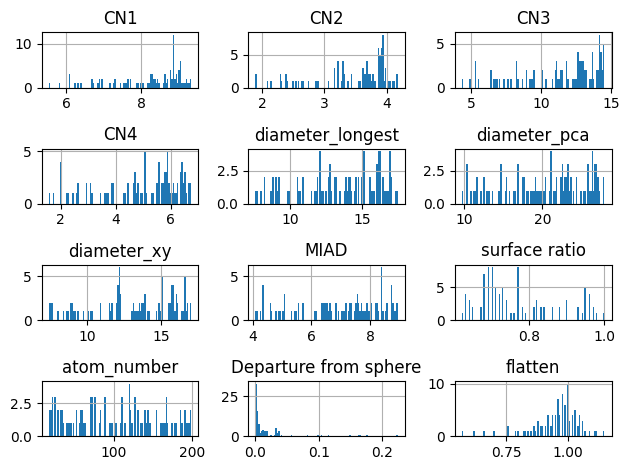

In [28]:
particles_descriptors=[]
bas=[]

for i in range(len(ini_atom_list)):
    particles_descriptors.append(descriptor_table(ini_atom_list[i]))
pdes=pd.DataFrame(particles_descriptors)
pdes.hist(bins=100)
plt.tight_layout()

In [36]:
view(ini_atom_list[5],viewer='x3d')

Text(0, 0.5, 'Fitness')

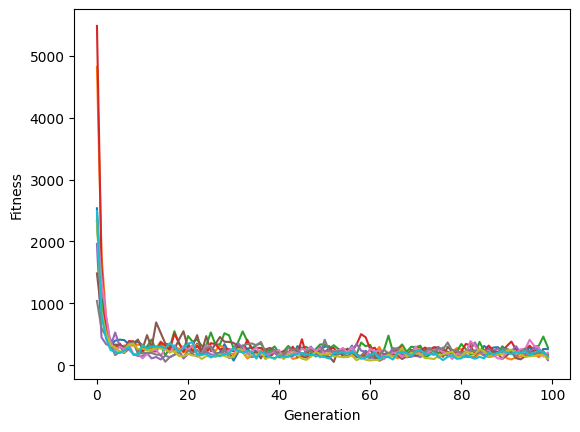

In [38]:
plt.figure()
for i in range(len(fitness_records)):
    plt.plot(fitness_records[i])
plt.xlabel("Generation")
plt.ylabel("Fitness")
# plt.plot(fitness_record)

In [12]:
pdes[pdes["flatten"]<0.8]
# view(last_atom_list[1])

,CN1,CN2,CN3,CN4,diameter_longest,diameter_pca,diameter_xy,MIAD,surface ratio,atom_number,Departure from sphere,flatten
48,5.37,2.00,3.42,1.32,10.63,11.69,9.41,4.74,1.00,19,0.211888,0.65
99,6.82,2.53,7.12,2.65,10.67,13.62,10.60,5.27,0.94,34,0.110374,0.74


In [29]:
def convex_particle(genome,lc,max_num_atoms):
    indices=[]
    num_lattice=max_num_atoms//2
    n_max=int(np.ceil(np.cbrt(num_lattice)))
    lattice_big=empty_lattice(lc,n_max,n_max,n_max)
    particle,_=recon_coordfromcodes(genome,lc,max_num_atoms)
    hull=ConvexHull(particle)
    for points in lattice_big:
        if is_point_in_hull(points,hull,lc):
            indices.extend(np.where(np.all(np.isclose(points,lattice_big,rtol=1e-1),axis=1))[0])
    print(len(indices))
    print(len(particle))
    genome_recon=np.zeros(len(lattice_big))
    for i in indices:
        genome_recon[i]=1
    return genome_recon
def is_point_in_hull(point,hull,lc):
    equations=hull.equations
    # print(np.all(np.dot(equations[:,:-1],point)+equations[:,-1]<=0))
    return np.all(np.dot(equations[:,:-1],point)+equations[:,-1]<=lc/(2*np.sqrt(2)))

In [30]:
import plotly.graph_objs as go
from plotly.offline import plot
g_reco=convex_particle(population[35],3.77,200)
points_add,lattice=recon_coordfromcodes(g_reco,3.77,200)
points,lattice=recon_coordfromcodes(population[35],3.77,200)
# Sample 3D points
 # 30 random points in 3D

# Compute the convex hull
hull = ConvexHull(points)

# Create a Plotly figure
fig = go.Figure()

# Add points to the plot
fig.add_trace(go.Scatter3d(
    x=points_add[:, 0], y=points_add[:, 1], z=points_add[:, 2],
    mode='markers',
    marker=dict(size=5, color='blue'),
    name='Points'
))

# Add the convex hull
for simplex in hull.simplices:
    simplex = np.append(simplex, simplex[0])  # cycle back to the first vertex
    fig.add_trace(go.Scatter3d(
        x=points[simplex, 0], y=points[simplex, 1], z=points[simplex, 2],
        mode='lines',
        line=dict(color='red', width=2),
        name='Convex Hull'
    ))

# Add the faces of the convex hull
faces = hull.simplices
for face in faces:
    x = [points[vertex, 0] for vertex in face]
    y = [points[vertex, 1] for vertex in face]
    z = [points[vertex, 2] for vertex in face]
    x.append(points[face[0], 0])
    y.append(points[face[0], 1])
    z.append(points[face[0], 2])
    fig.add_trace(go.Mesh3d(
        x=x, y=y, z=z,
        opacity=0.5,
        color='cyan',
        name='Convex Hull Face'
    ))

# Set plot title and labels
fig.update_layout(
    title='3D Convex Hull',
    scene=dict(
        xaxis_title='X Axis',
        yaxis_title='Y Axis',
        zaxis_title='Z Axis'
    )
)

# Show the plot
plot(fig)

50
50


'temp-plot.html'

In [9]:
particle,lattice=recon_coordfromcodes(population[1],3.77,200)
atom=Atoms(positions=particle,symbols=['Pt']*len(particle))
view(atom)

<Popen: returncode: None args: ['c:\\Users\\kaife\\anaconda3\\envs\\NN_work\...>

In [15]:
g_reco=convex_particle(population[35],3.77,200)
particle,lattice=recon_coordfromcodes(g_reco,3.77,200)
atom=Atoms(positions=particle,symbols=['Pt']*len(particle))
view(atom)

50
50


<Popen: returncode: None args: ['c:\\Users\\kaife\\anaconda3\\envs\\NN_work\...>